# **Computation Astrophysics and Geophysics PHY4830/AST4830** 
# **Assignment 1**

#### Author: Soumit Rao

### Equations to remember

$N_p + N_n = N_o = \text{const}$

$N_p=N_e$

$\frac{dN_n}{dt}= -\lambda N_n + \alpha N_pN_e$

##### Rewriting the above equation  gives us : 
$f(t, N_0)= -\lambda N_n + \alpha (N_0 - N_n)^2$ 

where $f(t,N_0)=\frac{dN_n}{dt}$

In [90]:
#packages
import numpy as np
import matplotlib.pyplot as plt
import time

#time was used to measure how long each function takes to execute; matplotlib for plotting and numpy for small mathematical operations 


In [103]:
# Fixed Parameters
lambda_1 = 0.00114 
alpha = 1.026e-39
N0 = 1e38
Steady_state = 0.90

#defining the function we have to solve
def dNdt(t , N):     #N is N_n here
    eqn = -lambda_1*N + alpha*(N0-N)**2
    return(eqn)


# **Explicit and Implicit Euler**

##### Explicit: $y_{n+1} = y_n + hy'_{n}$
##### Implicit: $y_{n+1} = y_n + hy'_{n+1}$

In [104]:
h = 0.05        #Step-size
t_start = 0     #initial
t_end = 500     #end 500s

In [105]:


def explicit_euler(x0 , y0 , h, t_end):
    steps = int((t_end - x0) / h) 
    x = x0
    y = y0
    x_list = [x]         #arrays
    y_list = [y]         #arrays
    
    for i in range(1, steps+1):
        y = y + h*dNdt(x , y) 
        x = x + h

        x_list.append(x) 
        y_list.append(y)
        
    return x_list ,y_list 

def implicit_euler(x0 , y0 , h , t_end):
    steps = int((t_end - x0) / h) 
    x = x0
    y = y0
    x_list = [x]         #arrays
    y_list = [y]         #arrays

    for i in range(1, steps+1):
        x_next = x + h
        y_predict = y + h * dNdt(x, y) # Predict the next y explicitly
        
        y = y + h * dNdt(x_next, y_predict) # Use predicted next y implicitly
        x = x_next

        x_list.append(x) 
        y_list.append(y)
    return x_list, y_list



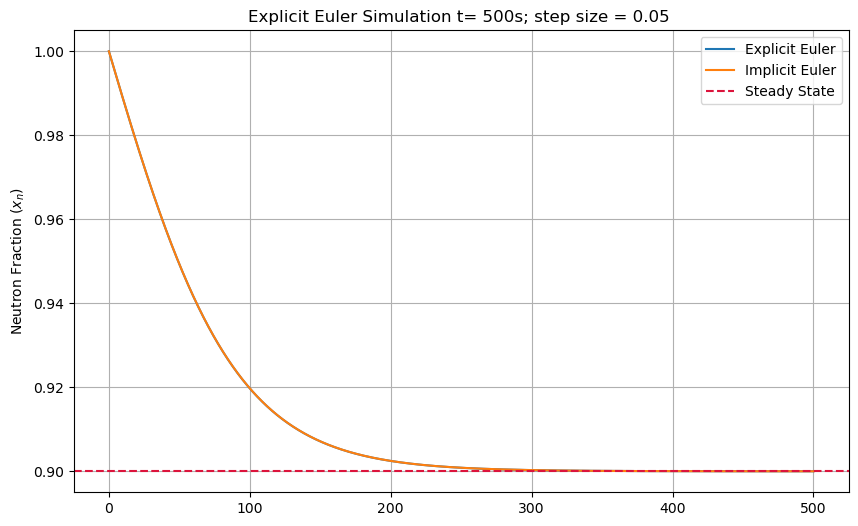

Explicit Euler converges to xn = 0.90000374188205
Implicit Euler converges to xn = 0.9000037808077627
time take by explicit Euler : 0.0068079158663749695s and implicit Euler : 0.011033582966774702s
(Rounded off)time take by explicit Euler : 0.00681s and implicit Euler : 0.01103s


In [106]:
# Plotting

h = 0.05
start_exp = time.perf_counter()    #measuring time taken by function to run
soln_exp_euler = explicit_euler(t_start , N0, h , 500)    #explicit
time_exp = time_exp = time.perf_counter() - start_exp

start_imp = time.perf_counter()
soln_imp_euler = implicit_euler(t_start , N0, h, 500)    #implicit
time_imp = time.perf_counter() - start_imp

xn_exp = [i/N0 for i in soln_exp_euler[1]]      #explicit
xn_imp = [i/N0 for i in soln_imp_euler[1]]      #implicit

plt.figure(figsize=(10,6))

plt.plot(soln_exp_euler[0] , xn_exp , label = 'Explicit Euler' )     #explicit
plt.plot(soln_imp_euler[0] , xn_imp , label = 'Implicit Euler' )     #implicit
plt.axhline(0.90 , linestyle ='--' , color = 'crimson' , label = 'Steady State')
plt.ylabel("Neutron Fraction ($x_n$)")
plt.title(f"Explicit Euler Simulation t= 500s; step size = {h} ")
plt.legend()
plt.grid(True)
plt.show()

print(f"Explicit Euler converges to xn = {xn_exp[-1]}")
print(f"Implicit Euler converges to xn = {xn_imp[-1]}")
print(f"time take by explicit Euler : {time_exp}s and implicit Euler : {time_imp}s")

print(f"(Rounded off)time take by explicit Euler : {time_exp:.5f}s and implicit Euler : {time_imp:.5f}s")



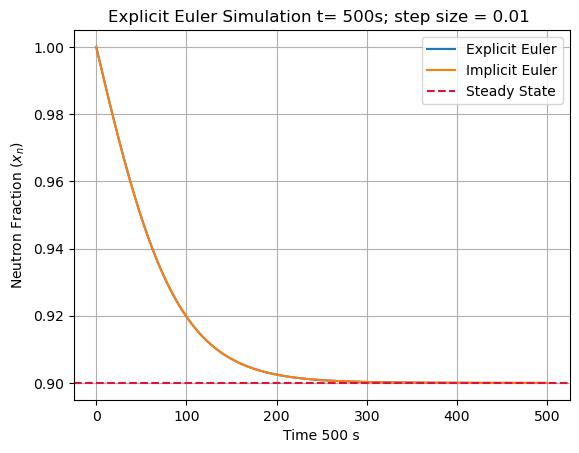

h = 0.01 s
Explicit Euler: xn(500) ≈ 0.9000037574
Implicit Euler: xn(500) ≈ 0.9000037652



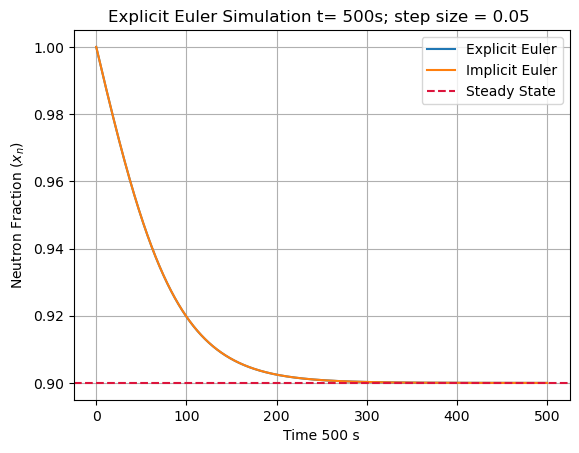

h = 0.05 s
Explicit Euler: xn(500) ≈ 0.9000037419
Implicit Euler: xn(500) ≈ 0.9000037808



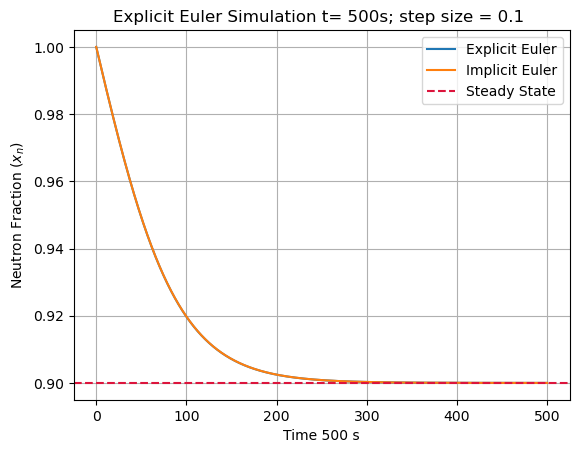

h = 0.1 s
Explicit Euler: xn(500) ≈ 0.9000037225
Implicit Euler: xn(500) ≈ 0.9000038005



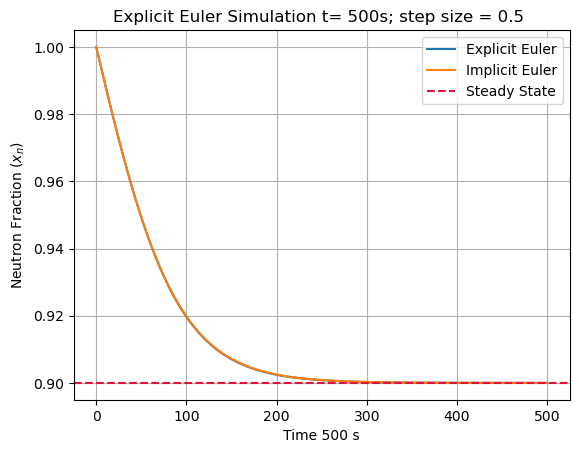

h = 0.5 s
Explicit Euler: xn(500) ≈ 0.9000035705
Implicit Euler: xn(500) ≈ 0.9000039636



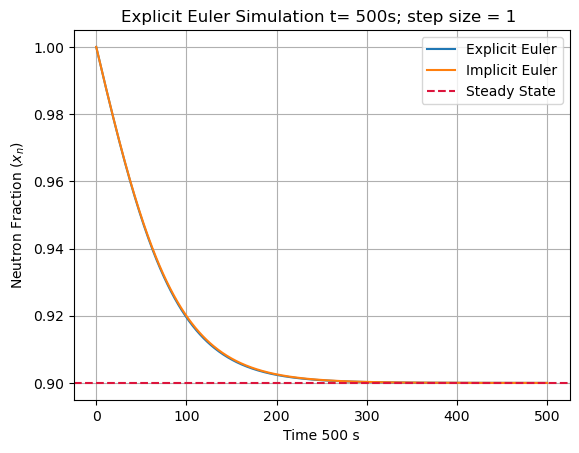

h = 1 s
Explicit Euler: xn(500) ≈ 0.9000033869
Implicit Euler: xn(500) ≈ 0.9000041826



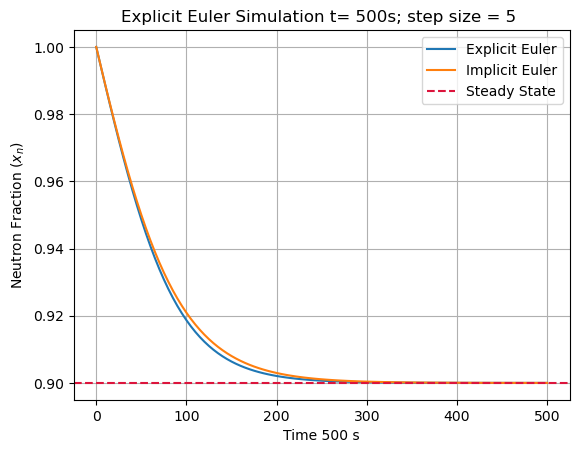

h = 5 s
Explicit Euler: xn(500) ≈ 0.9000021574
Implicit Euler: xn(500) ≈ 0.9000067708



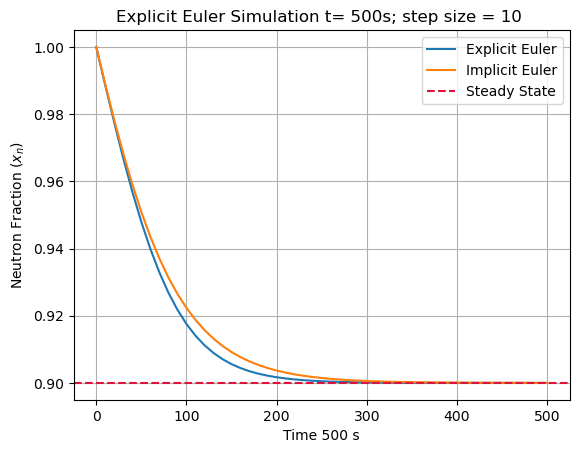

h = 10 s
Explicit Euler: xn(500) ≈ 0.9000011278
Implicit Euler: xn(500) ≈ 0.9000141046



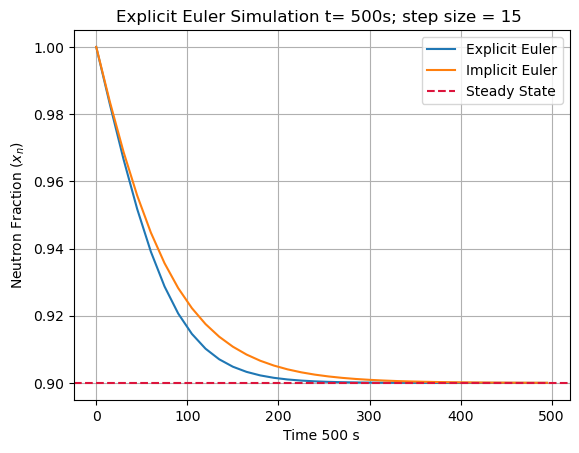

h = 15 s
Explicit Euler: xn(500) ≈ 0.9000005940
Implicit Euler: xn(500) ≈ 0.9000367651



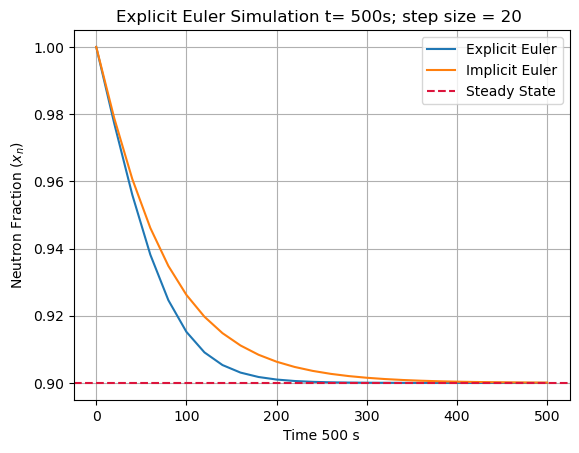

h = 20 s
Explicit Euler: xn(500) ≈ 0.9000002029
Implicit Euler: xn(500) ≈ 0.9000915446



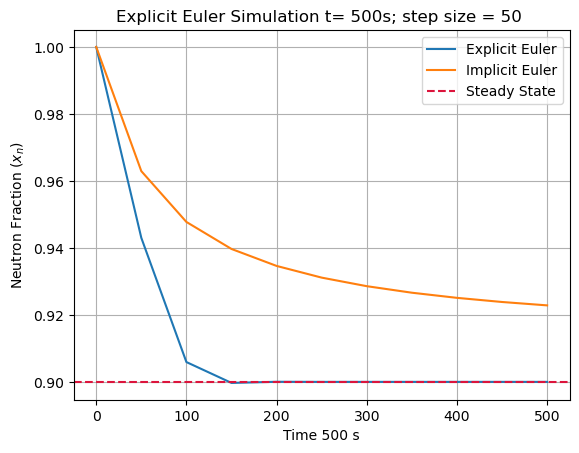

h = 50 s
Explicit Euler: xn(500) ≈ 0.9000000000
Implicit Euler: xn(500) ≈ 0.9228396021



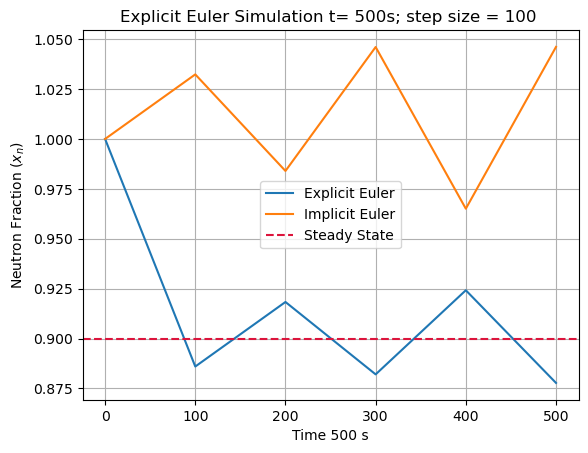

h = 100 s
Explicit Euler: xn(500) ≈ 0.8777888066
Implicit Euler: xn(500) ≈ 1.0461013624



In [95]:
#multiple values of h
h_vals = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 50, 100]


# plt.figure(figsize=(15,10))

for h in h_vals:
    soln_exp_euler = explicit_euler(t_start , N0, h, 500)    #explicit
    soln_imp_euler = implicit_euler(t_start , N0, h, 500)    #implicit
    

    xn_exp = [i/N0 for i in soln_exp_euler[1]]      #explicit
    xn_imp = [i/N0 for i in soln_imp_euler[1]]      #implicit



    plt.plot(soln_exp_euler[0] , xn_exp , label = 'Explicit Euler' )     #explicit
    plt.plot(soln_imp_euler[0] , xn_imp , label = 'Implicit Euler' )     #implicit
    
    plt.axhline(0.90 , linestyle ='--' , color = 'crimson' , label = 'Steady State')
    plt.xlabel(f"Time {t_end} s")
    plt.ylabel("Neutron Fraction ($x_n$)")
    plt.title(f"Explicit Euler Simulation t= 500s; step size = {h} ")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"h = {h} s")
    print(f"Explicit Euler: xn(500) ≈ {xn_exp[-1]:.10f}")
    print(f"Implicit Euler: xn(500) ≈ {xn_imp[-1]:.10f}")
    print()

# **Runge-Kutta 4th order method**

###### References
1) Condensed lecture notes
2) Geeksforgeeks https://www.geeksforgeeks.org/dsa/runge-kutta-4th-order-method-solve-differential-equation/

In [96]:
 #notation from lecture notes
h = 0.001     #Step-size
t_start = 0     #initial
t_end = 500    #end

 


def rk4(x0, y0, h, t_end):

    x_list = [x0]
    y_list = [y0]

    steps = int((t_end - x0) / h)

    for i in range(steps):

        k1 = h * dNdt(x0, y0)
        k2 = h * dNdt(x0 + 0.5*h, y0 + 0.5*k1)
        k3 = h * dNdt(x0 + 0.5*h, y0 + 0.5*k2)
        k4 = h * dNdt(x0 + h, y0 + k3)

        y0 = y0 + (k1 + 2*k2 + 2*k3 + k4)/6
        x0 = x0 + h

        x_list.append(x0)
        y_list.append(y0)

    return x_list, y_list

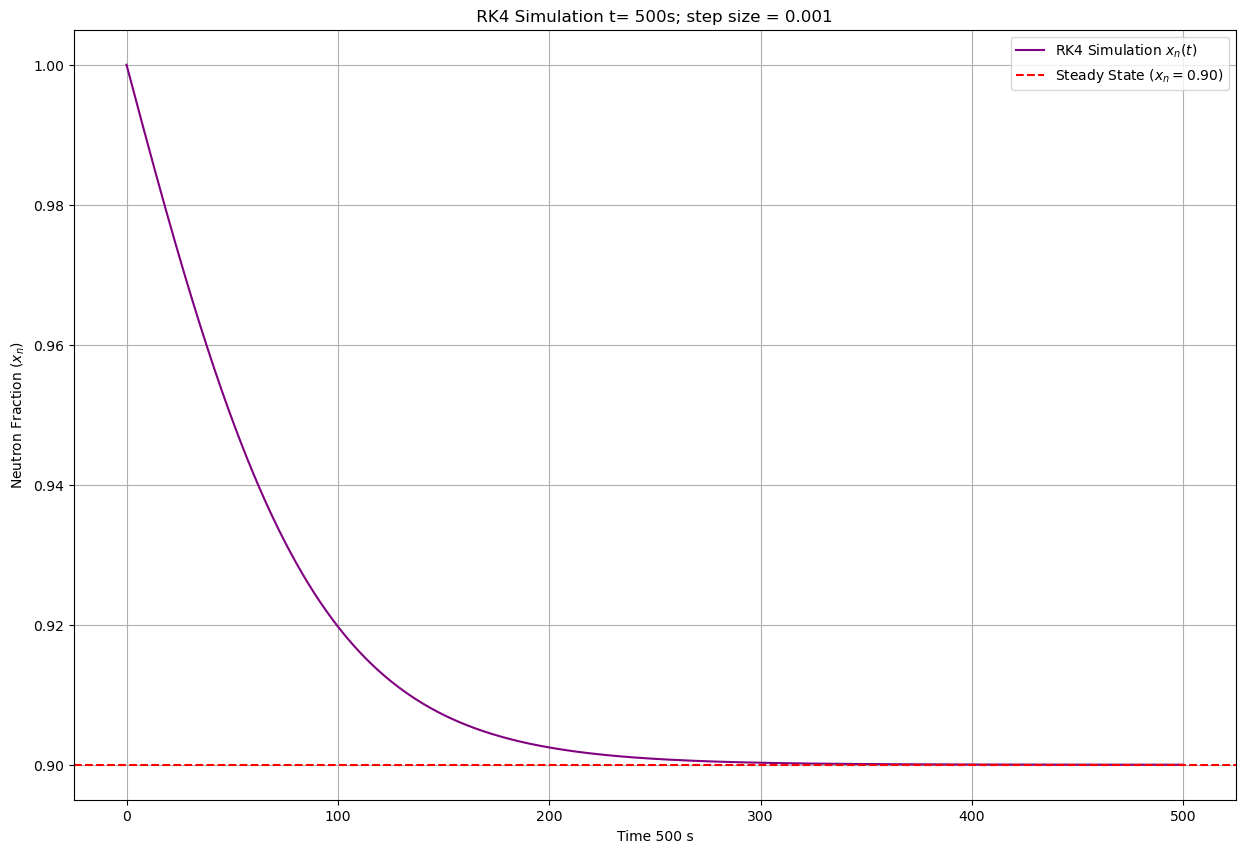

time take by Runge Kutta method (4th order): 0.5098089159000665s 
 (Rounder off) time take by Runge Kutta method (4th order): 0.50981s 


In [97]:
# h = 5

start_rk4 = time.perf_counter()
times, densities = rk4(t_start, N0, h, 500)
neutron_fractions = [N / N0 for N in densities]
time_rk4 = time.perf_counter() - start_rk4

plt.figure(figsize=(15,10))
plt.plot(times, neutron_fractions, label="RK4 Simulation $x_n(t)$" , color ='purple')
plt.axhline(0.90, color="red", linestyle="--", label="Steady State ($x_n = 0.90$)")
plt.xlabel(f"Time {t_end} s")
plt.ylabel("Neutron Fraction ($x_n$)")
plt.title(f" RK4 Simulation t= 500s; step size = {h} ")
plt.legend()
plt.grid(True)
plt.show()


print(f"time take by Runge Kutta method (4th order): {time_rk4}s ")
print(f" (Rounder off) time take by Runge Kutta method (4th order): {time_rk4:.5f}s ")



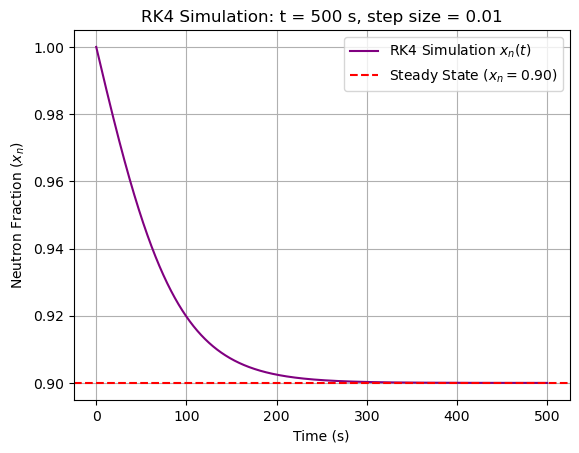

h = 0.01 s
Time taken by RK4: 0.06438 s
x_n(500) ≈ 0.9000037613



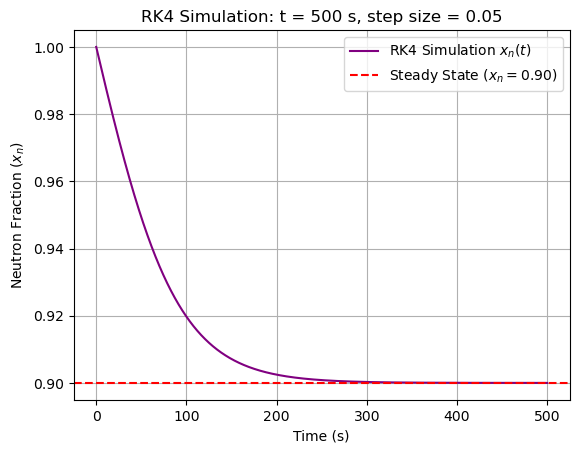

h = 0.05 s
Time taken by RK4: 0.01140 s
x_n(500) ≈ 0.9000037613



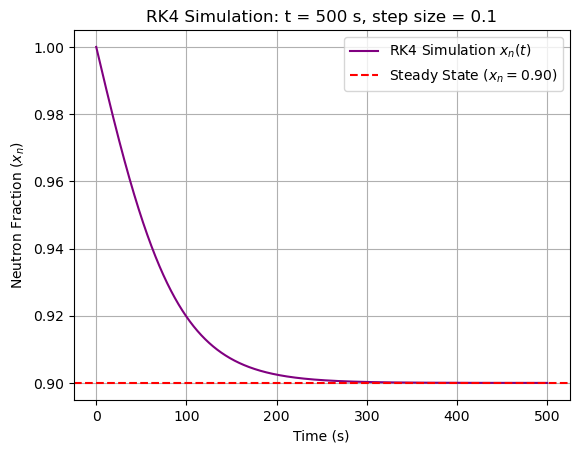

h = 0.1 s
Time taken by RK4: 0.00509 s
x_n(500) ≈ 0.9000037613



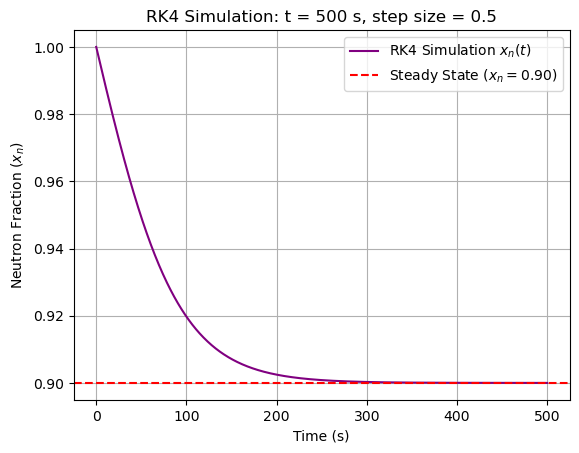

h = 0.5 s
Time taken by RK4: 0.00115 s
x_n(500) ≈ 0.9000037613



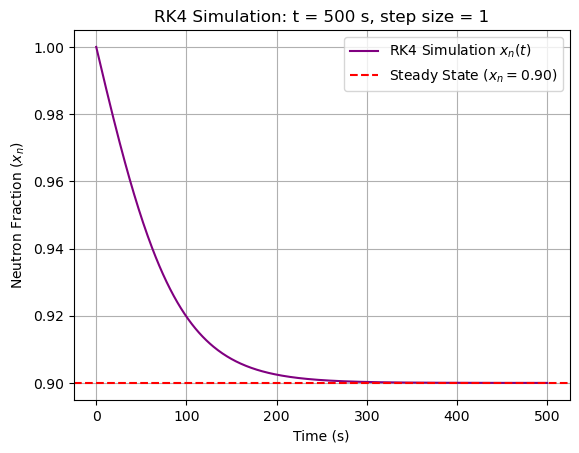

h = 1 s
Time taken by RK4: 0.00151 s
x_n(500) ≈ 0.9000037613



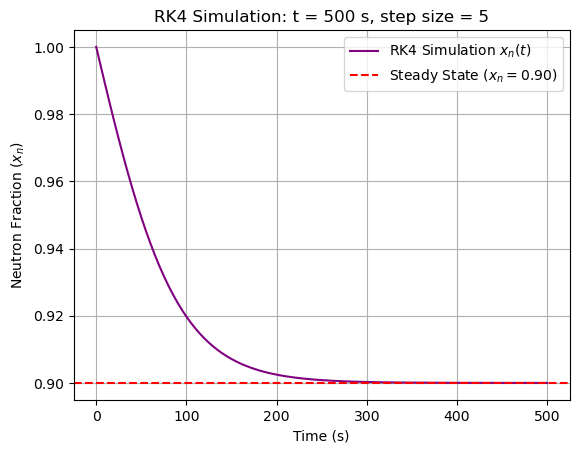

h = 5 s
Time taken by RK4: 0.00014 s
x_n(500) ≈ 0.9000037613



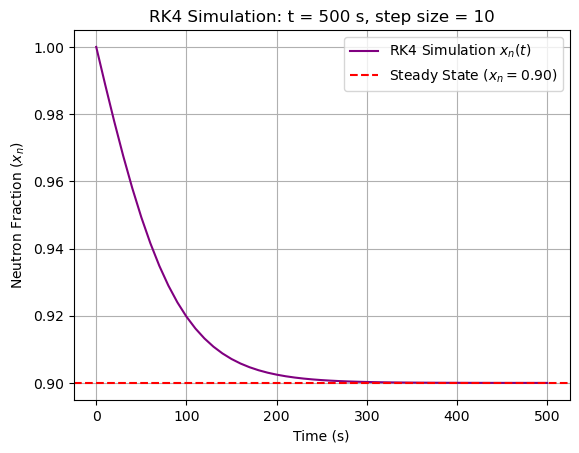

h = 10 s
Time taken by RK4: 0.00008 s
x_n(500) ≈ 0.9000037620



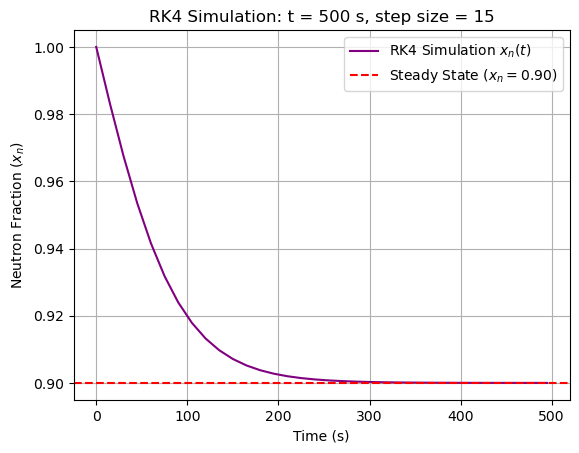

h = 15 s
Time taken by RK4: 0.00005 s
x_n(500) ≈ 0.9000041959



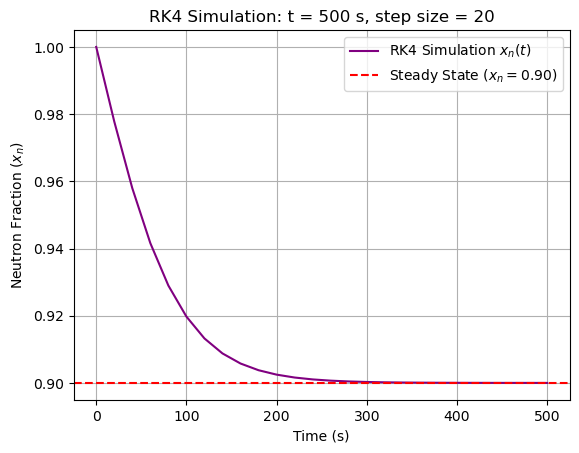

h = 20 s
Time taken by RK4: 0.00005 s
x_n(500) ≈ 0.9000037751



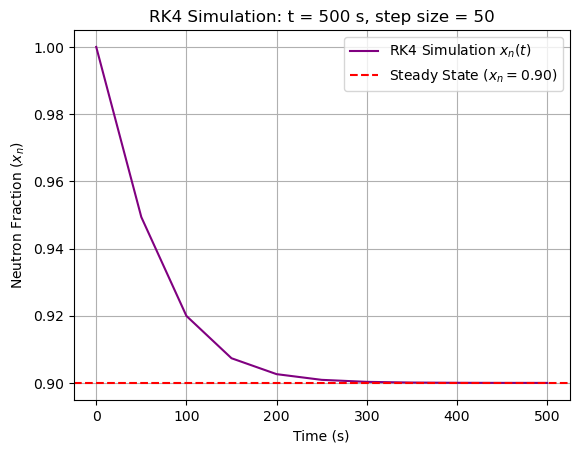

h = 50 s
Time taken by RK4: 0.00002 s
x_n(500) ≈ 0.9000047816



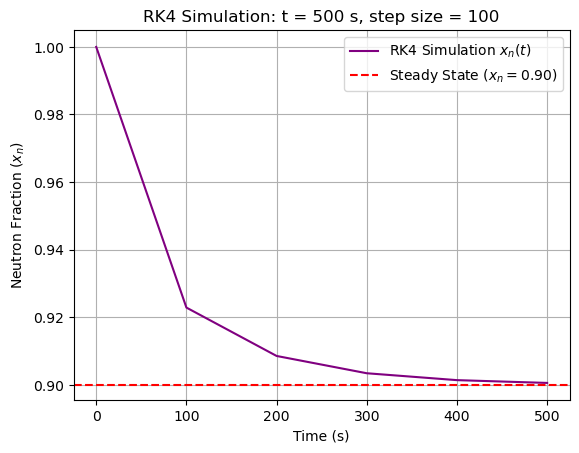

h = 100 s
Time taken by RK4: 0.00001 s
x_n(500) ≈ 0.9005576380



In [98]:
h_vals = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 50, 100]

for h in h_vals:

    start_rk4 = time.perf_counter()
    times, densities = rk4(t_start, N0, h, 500)
    neutron_fractions = [N / N0 for N in densities]
    time_rk4 = time.perf_counter() - start_rk4
    
    plt.plot(times,neutron_fractions,label="RK4 Simulation $x_n(t)$",color="purple")
    plt.axhline(0.90,color="red",linestyle="--",label="Steady State ($x_n = 0.90$)")
    plt.xlabel("Time (s)")
    plt.ylabel("Neutron Fraction ($x_n$)")
    plt.title(f"RK4 Simulation: t = 500 s, step size = {h}")

    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"h = {h} s")
    print(f"Time taken by RK4: {time_rk4:.5f} s")
    print(f"x_n(500) ≈ {neutron_fractions[-1]:.10f}")
    print()

# **Bulirsch-Stoer**

##### References
1) Condensed lecture notes
2) XMDS http://www.xmds.org/bulirschStoer.html
3) Numerical Recipes

In [99]:
#params
H = 10     #Step-size
t_start = 0     #initial
t_end = 500    #end


def midpoint(x0, y0, H, nsteps):
    h = H / nsteps
    z0 = y0
    z1 = z0 + h*dNdt(x0, z0)

    for i in range(1, nsteps):
        x_i = x0 + i*h
        z2 = z0 + 2*h*dNdt(x_i, z1)
        z0 = z1
        z1 = z2

    y_n = 0.5*(z1 + z0 + h*dNdt(x0 + H, z1))
    return y_n

def richardson(r, k):
    for j in range(k - 1, 0, -1):
        const = (k / (k - 1.0)) ** (2.0 * (k - j))
        r[j] = (const * r[j + 1] - r[j]) / (const - 1.0)
        
def BS_step(x0, y0, H, kmax=8):        
    r = [0.0]*(kmax + 1)      
    for k in range(1, kmax + 1):
        nsteps = k              
        r[k] = midpoint(x0, y0, H, nsteps)
        richardson(r, k)
    return r[1]          
  
def BS(x, y, H, t_end, kmax=8):
    x0 = x
    y0 = y
    x_list = [x0]
    y_list = [y0]

    steps = int((t_end - x0) / H)    
    for i in range(1, steps + 1):
        y0 = BS_step(x0, y0, H, kmax)
        x0 = x0 + H
        x_list.append(x0)
        y_list.append(y0)

    return x_list, y_list




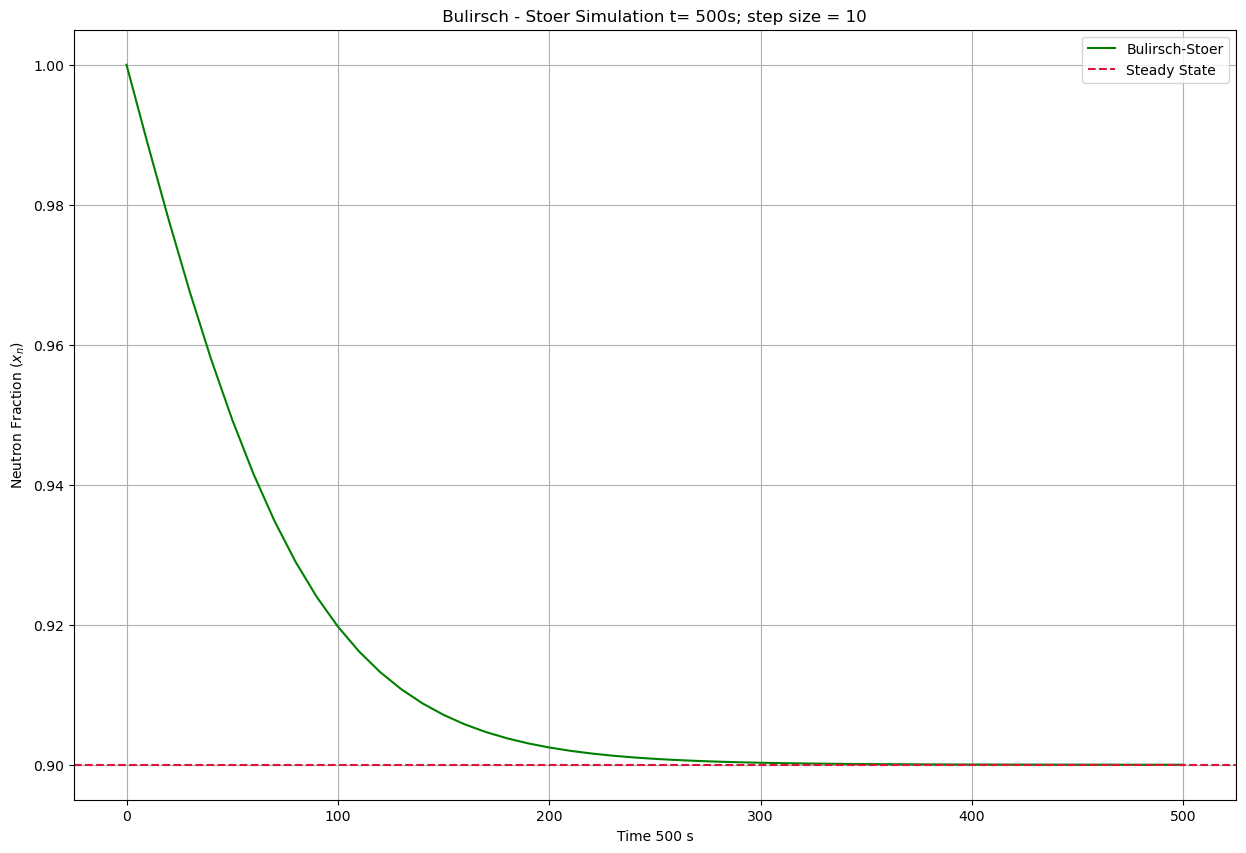

x_n(500) ≈ 0.9000037531
time taken by Bulirsch-Stoer method : 0.0016428341623395681s
(Rounded off) time taken by Bulirsch-Stoer method : 0.00164s


In [100]:
star_bs = time.perf_counter()
x_list, y_list = BS(t_start, N0, 10, 500)     
xn_bs = [n/N0 for n in y_list]
time_bs = time.perf_counter() - star_bs

plt.figure(figsize=(15,10))
plt.plot(x_list, xn_bs, label='Bulirsch-Stoer' , color = 'green')
plt.xlabel(f"Time {t_end} s")
plt.ylabel("Neutron Fraction ($x_n$)")
plt.axhline(0.90 , linestyle = "--", label="Steady State" , color = 'crimson')
plt.title(f" Bulirsch - Stoer Simulation t= 500s; step size = {H} ")
plt.legend()
plt.grid(True)
plt.show()

print(f"x_n(500) ≈ {xn_bs[-1]:.10f}")
print(f"time taken by Bulirsch-Stoer method : {time_bs}s")
print(f"(Rounded off) time taken by Bulirsch-Stoer method : {time_bs:.5f}s")

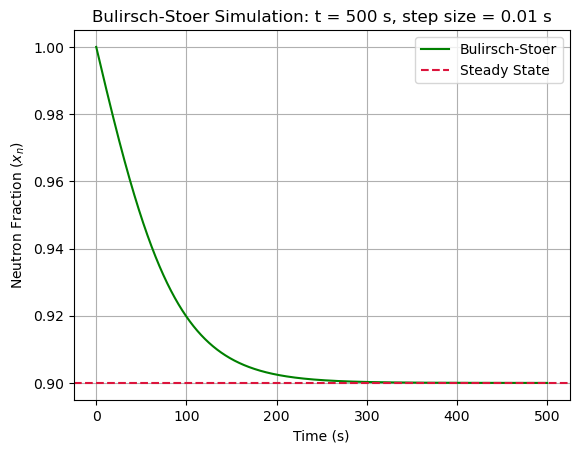

h = 0.01 s
Time taken by Bulirsch-Stoer: 0.96486 
x_n(500) ≈ 0.9000037613



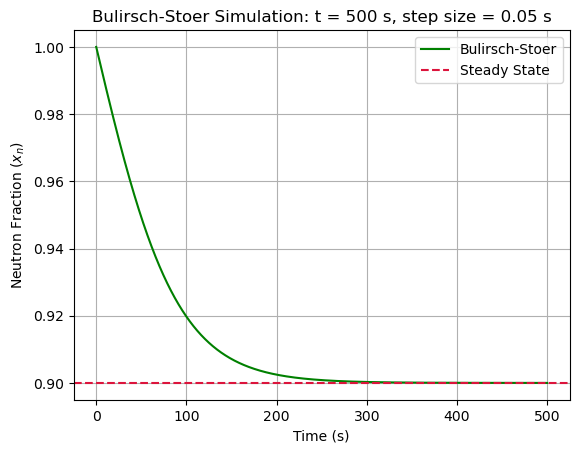

h = 0.05 s
Time taken by Bulirsch-Stoer: 0.18912 
x_n(500) ≈ 0.9000037613



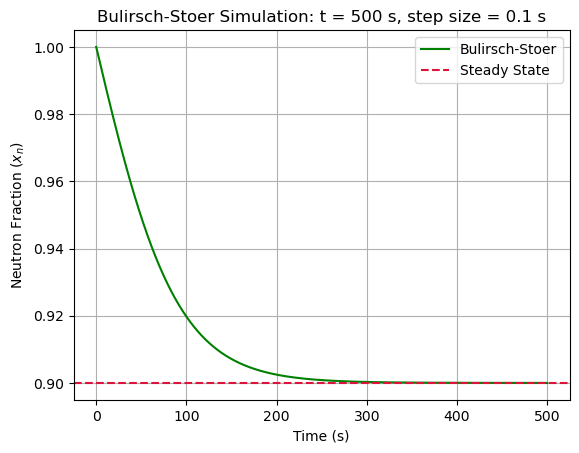

h = 0.1 s
Time taken by Bulirsch-Stoer: 0.09635 
x_n(500) ≈ 0.9000037613



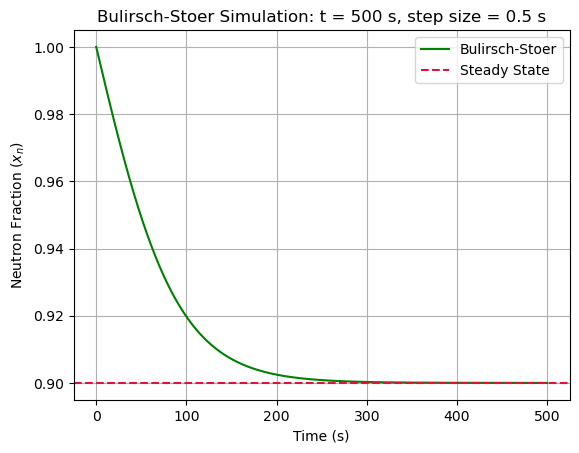

h = 0.5 s
Time taken by Bulirsch-Stoer: 0.01991 
x_n(500) ≈ 0.9000037613



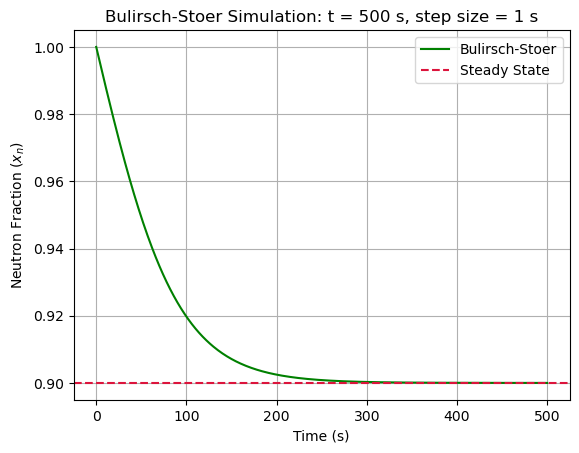

h = 1 s
Time taken by Bulirsch-Stoer: 0.00988 
x_n(500) ≈ 0.9000037613



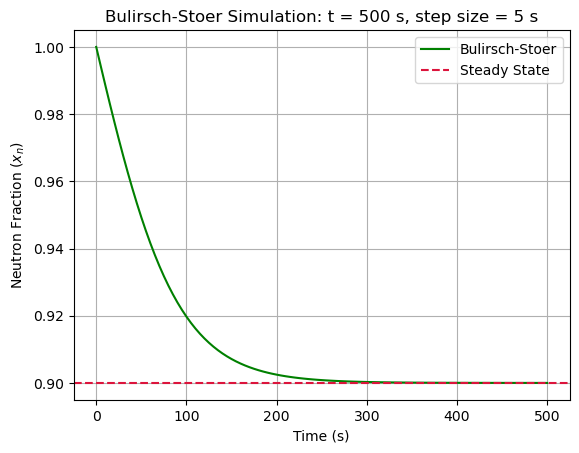

h = 5 s
Time taken by Bulirsch-Stoer: 0.00196 
x_n(500) ≈ 0.9000037605



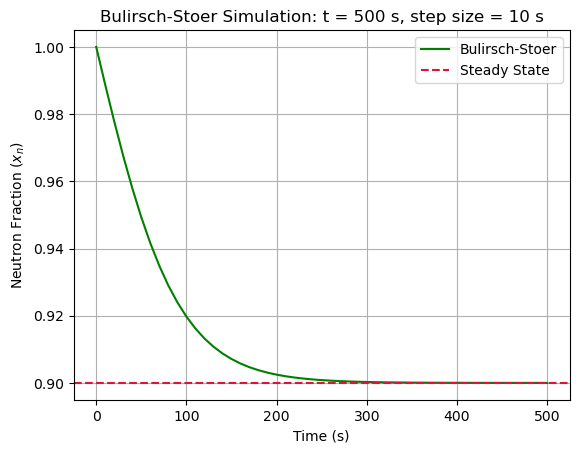

h = 10 s
Time taken by Bulirsch-Stoer: 0.00102 
x_n(500) ≈ 0.9000037531



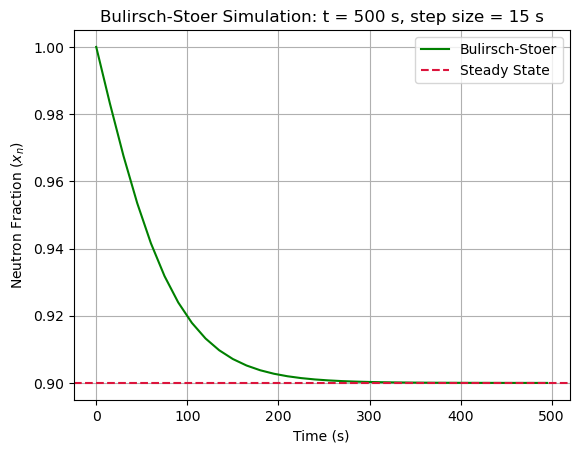

h = 15 s
Time taken by Bulirsch-Stoer: 0.00066 
x_n(500) ≈ 0.9000041545



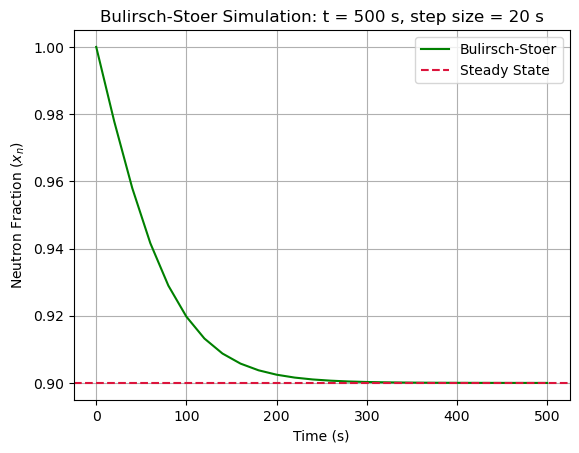

h = 20 s
Time taken by Bulirsch-Stoer: 0.00057 
x_n(500) ≈ 0.9000036643



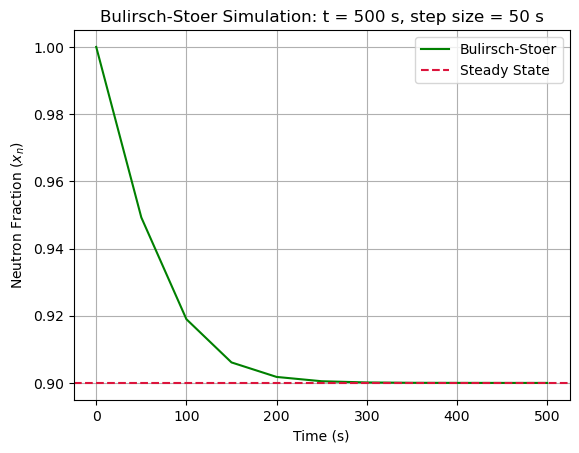

h = 50 s
Time taken by Bulirsch-Stoer: 0.00021 
x_n(500) ≈ 0.9000008365



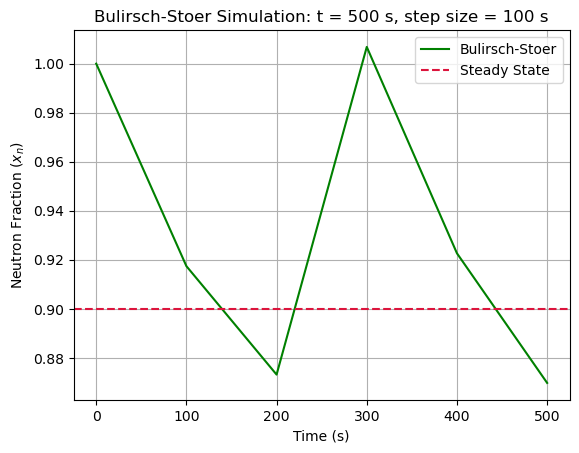

h = 100 s
Time taken by Bulirsch-Stoer: 0.00011 
x_n(500) ≈ 0.8697676974



In [101]:
h_vals = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 50, 100]

for h in h_vals:
    start_bs = time.perf_counter()
    x_list, y_list = BS(t_start, N0, h, 500)
    xn_bs = [n / N0 for n in y_list]
    time_bs = time.perf_counter() - start_bs

    plt.plot(x_list,xn_bs,label="Bulirsch-Stoer",color="green")
    plt.axhline(0.90,linestyle="--",label="Steady State",color="crimson")
    plt.xlabel("Time (s)")
    plt.ylabel("Neutron Fraction ($x_n$)")
    plt.title(f"Bulirsch-Stoer Simulation: t = 500 s, step size = {h} s")

    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"h = {h} s")
    print(f"Time taken by Bulirsch-Stoer: {time_bs:.5f} ")
    print(f"x_n(500) ≈ {xn_bs[-1]:.10f}")
    print()

# Comparing all the methods

### Plotting all the methods 

h = 0.5
  Explicit Euler : xn = 0.900004
  Implicit Euler : xn = 0.900004
  RK4            : xn = 0.900004
  Bulirsch-Stoer : xn = 0.900004

h = 1
  Explicit Euler : xn = 0.900003
  Implicit Euler : xn = 0.900004
  RK4            : xn = 0.900004
  Bulirsch-Stoer : xn = 0.900004

h = 5
  Explicit Euler : xn = 0.900002
  Implicit Euler : xn = 0.900007
  RK4            : xn = 0.900004
  Bulirsch-Stoer : xn = 0.900004

h = 25
  Explicit Euler : xn = 0.900000
  Implicit Euler : xn = 0.900267
  RK4            : xn = 0.900004
  Bulirsch-Stoer : xn = 0.900004

h = 50
  Explicit Euler : xn = 0.900000
  Implicit Euler : xn = 0.922840
  RK4            : xn = 0.900005
  Bulirsch-Stoer : xn = 0.900001

h = 100
  Explicit Euler : xn = 0.877789
  Implicit Euler : xn = 1.046101
  RK4            : xn = 0.900558
  Bulirsch-Stoer : xn = 0.869768



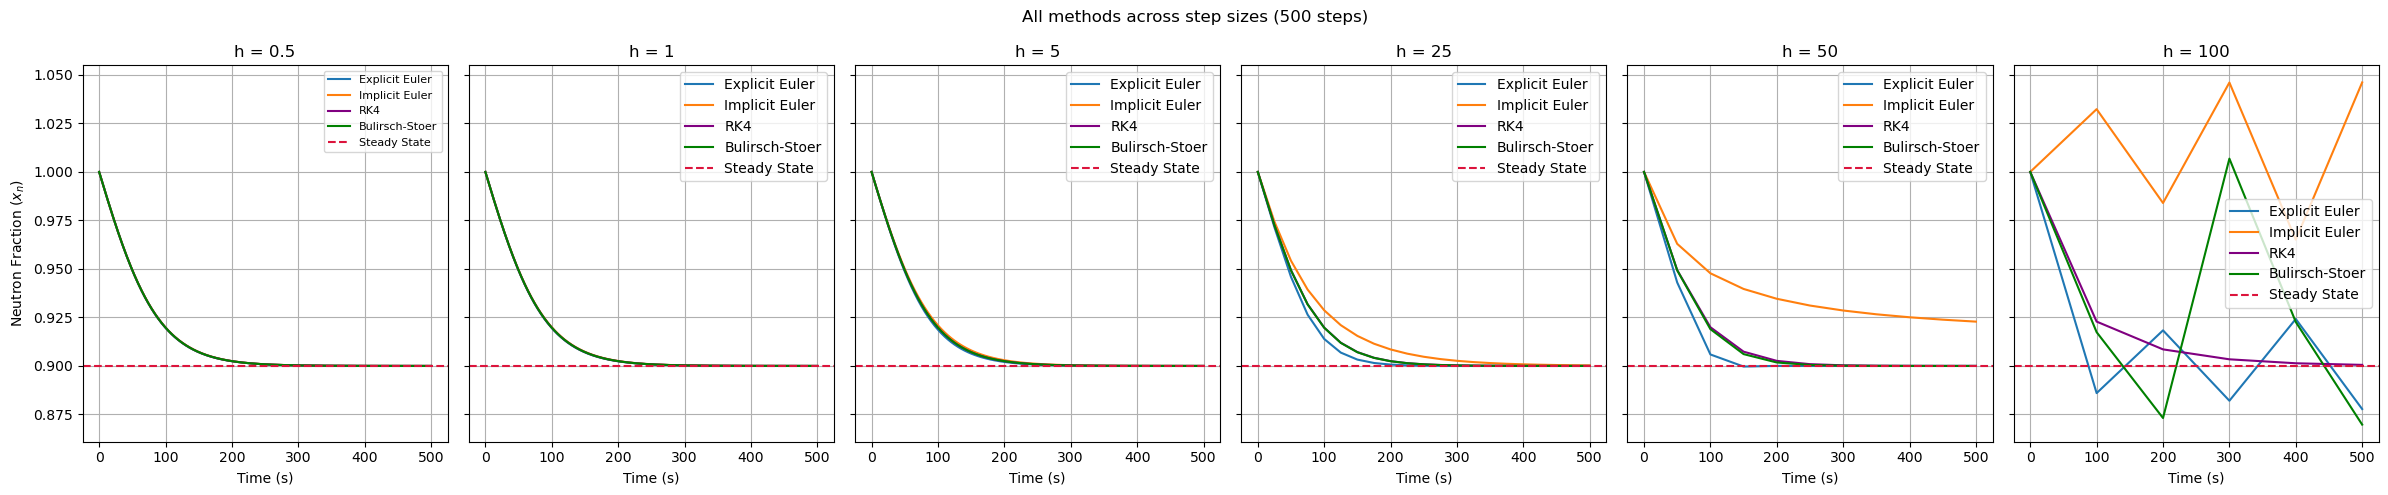

In [102]:

h_vals_compare = [0.5, 1, 5,25 , 50, 100]  # at most 5

fig, axes = plt.subplots(1, len(h_vals_compare), figsize=(24, 5), sharey=True)

for ax, h in zip(axes, h_vals_compare):
    t_exp, y_exp = explicit_euler(t_start, N0, h, 500)
    t_imp, y_imp = implicit_euler(t_start, N0, h, 500)
    t_rk4, y_rk4 = rk4(t_start, N0, h, 500)
    t_bs, y_bs = BS(t_start, N0, h, 500)

    xn_exp = [y / N0 for y in y_exp]
    xn_imp = [y / N0 for y in y_imp]
    xn_rk4 = [y / N0 for y in y_rk4]
    xn_bs = [y / N0 for y in y_bs]

    ax.plot(t_exp, xn_exp, label="Explicit Euler")
    ax.plot(t_imp, xn_imp, label="Implicit Euler")
    ax.plot(t_rk4, xn_rk4, label="RK4", color="purple")
    ax.plot(t_bs, xn_bs, label="Bulirsch-Stoer", color="green")
    ax.axhline(0.90, linestyle="--", color="crimson", label="Steady State")
    ax.legend()
    ax.set_title(f"h = {h}")
    ax.set_xlabel("Time (s)")
    ax.grid(True)

    print(f"h = {h}")
    print(f"  Explicit Euler : xn = {xn_exp[-1]:.6f}")
    print(f"  Implicit Euler : xn = {xn_imp[-1]:.6f}")
    print(f"  RK4            : xn = {xn_rk4[-1]:.6f}")
    print(f"  Bulirsch-Stoer : xn = {xn_bs[-1]:.6f}\n")

axes[0].set_ylabel("Neutron Fraction ($x_n$)")
axes[0].legend(fontsize=8)  

fig.suptitle("All methods across step sizes (500 steps)")
plt.tight_layout()
plt.show()

## *Final Observations*
1) Since Runge - Kutta is a 4th order accurate method it is the most efficient out of all the other methods providing accuracy at large step-sizes as well. For step sizes h<50 , RK4 outperforms lower-order explicit methods by maintaining high accuracy without requiring sub-stepping.
3) Explicit Euler is highly efficient per step but it's first-order accuracy O(h) makes it unstable and inaccurate at large step sizes.
4) Bulirsch-Stoer requires the highest computational work per macro-step due to multiple sub-step evaluations, providing near-exact precision at small steps but breaking down when large macro-steps exceed its convergence limit. It is highly computationally expensive per macro-step due to the multi-substep sequence (n=2,4,6). If the macro-step H is chosen too large (H≥50), the
extrapolation fails to converge


Runge - Kutta is the most efficient out of all the methods used for this assignment 
